In [62]:
import pandas as pd

df = pd.read_json("data/events/7298.json")
df = pd.json_normalize(df.to_dict(orient="records"))
print(df.head())
print(df.columns)

                                     id  index  period  \
0  0b483cd2-1d36-49a0-85c2-149a9de553df      1       1   
1  2c873afb-73bb-48a1-9fd5-bfe1400b4a83      2       1   
2  040940a1-5972-431e-b6ac-e723edd8e7c2      3       1   
3  5ba286bd-c397-4ac4-b12f-6bace943afce      4       1   
4  2a456ec2-352c-499b-b5cc-e68bf84c7e9a      5       1   

                timestamp  minute  second  possession  duration  \
0 2026-05-10 00:00:00.000       0       0           1      0.00   
1 2026-05-10 00:00:00.000       0       0           1      0.00   
2 2026-05-10 00:00:00.000       0       0           1      7.96   
3 2026-05-10 00:00:00.000       0       0           1      8.16   
4 2026-05-10 00:00:00.100       0       0           2      0.00   

                           related_events  player  ...  \
0                                     NaN     NaN  ...   
1                                     NaN     NaN  ...   
2  [5ba286bd-c397-4ac4-b12f-6bace943afce]     NaN  ...   
3  [040940a1-597

In [63]:
print(df['type.name'].value_counts().head(10))

type.name
Pass             1000
Ball Receipt*     923
Carry             833
Pressure          470
Ball Recovery     110
Dribble            58
Block              49
Duel               46
Goal Keeper        40
Miscontrol         39
Name: count, dtype: int64


In [64]:
passes = df[
    (df['type.name'] == 'Pass') &
    (df['team.name'] == 'Chelsea FCW')
].copy()

print(passes.columns)

Index(['id', 'index', 'period', 'timestamp', 'minute', 'second', 'possession',
       'duration', 'related_events', 'player',
       ...
       'substitution.replacement.name', 'shot.one_on_one',
       'foul_committed.advantage', 'foul_won.advantage',
       'injury_stoppage.in_chain', 'foul_committed.offensive',
       'foul_won.defensive', 'bad_behaviour.card.id',
       'bad_behaviour.card.name', 'ball_recovery.offensive'],
      dtype='object', length=120)


In [65]:
# Dropping incomplete passes 

passes = passes.dropna(subset=['pass.recipient.name'])

In [66]:
pass_links = passes.groupby(
    ['player.name', 'pass.recipient.name']
).size().reset_index(name='count')

print(pass_links.head())

                  player.name            pass.recipient.name  count
0  Anita Amma Ankyewah Asante  Crystal Alyssia Dunn Soubrier      1
1  Anita Amma Ankyewah Asante                    Drew Spence      1
2  Anita Amma Ankyewah Asante                Francesca Kirby      2
3  Anita Amma Ankyewah Asante          Hannah Jayne Blundell      3
4  Anita Amma Ankyewah Asante       Magdalena Lilly Eriksson     13


In [67]:
import numpy as np

passes['x'] = passes['location'].apply(lambda loc: loc[0])
passes['y'] = passes['location'].apply(lambda loc: loc[1])

avg_positions = passes.groupby('player.name').agg({
    'x': 'mean',
    'y': 'mean'
}).reset_index()

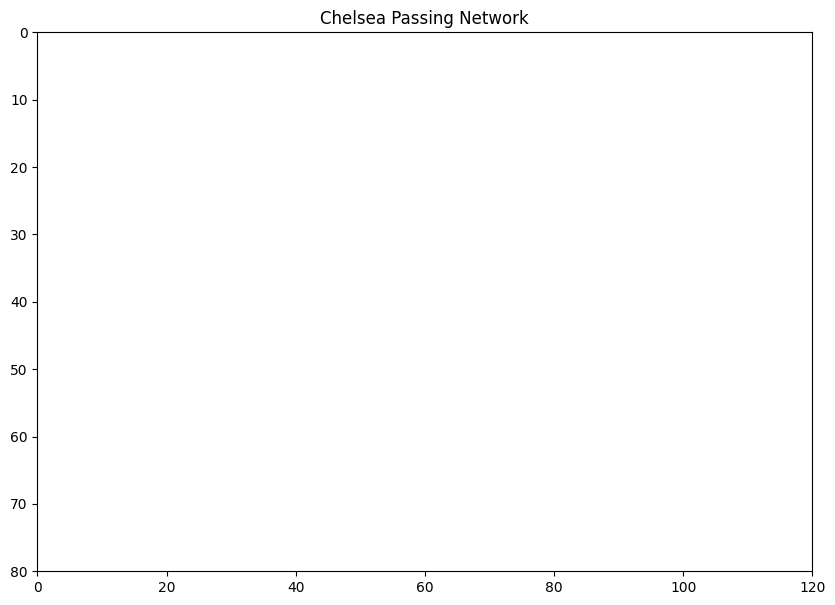

In [68]:
# Plotting the pitch
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 7))

# Draw pitch (basic)
ax.set_xlim(0, 120)
ax.set_ylim(0, 80)
ax.set_title("Chelsea Passing Network")

# Flip y-axis (football convention)
ax.invert_yaxis()

In [69]:
passes['end_x'] = passes['pass.end_location'].apply(lambda loc: loc[0])
passes['end_y'] = passes['pass.end_location'].apply(lambda loc: loc[1])

In [70]:
# Passers (start locations)
passers = passes[['player.name', 'x', 'y']].rename(
    columns={'player.name': 'player'}
)

# Receivers (end locations)
receivers = passes[['pass.recipient.name', 'end_x', 'end_y']].rename(
    columns={
        'pass.recipient.name': 'player',
        'end_x': 'x',
        'end_y': 'y'
    }
)

# Combine them
all_players = pd.concat([passers, receivers])

In [71]:
avg_positions = all_players.groupby('player').agg({
    'x': 'mean',
    'y': 'mean'
}).reset_index()

In [72]:
pos_dict = avg_positions.set_index('player')[['x', 'y']].to_dict('index')

In [73]:
for _, row in pass_links.iterrows():
    passer = row['player.name']
    receiver = row['pass.recipient.name']

    if passer in pos_dict and receiver in pos_dict:
        x1, y1 = pos_dict[passer]['x'], pos_dict[passer]['y']
        x2, y2 = pos_dict[receiver]['x'], pos_dict[receiver]['y']

        ax.plot([x1, x2], [y1, y2], linewidth=1)

In [74]:
# The results
print(len(pass_links))
print(len(avg_positions))

plt.show()
plt.savefig("passing_network_improved.png")

115
14


<Figure size 640x480 with 0 Axes>

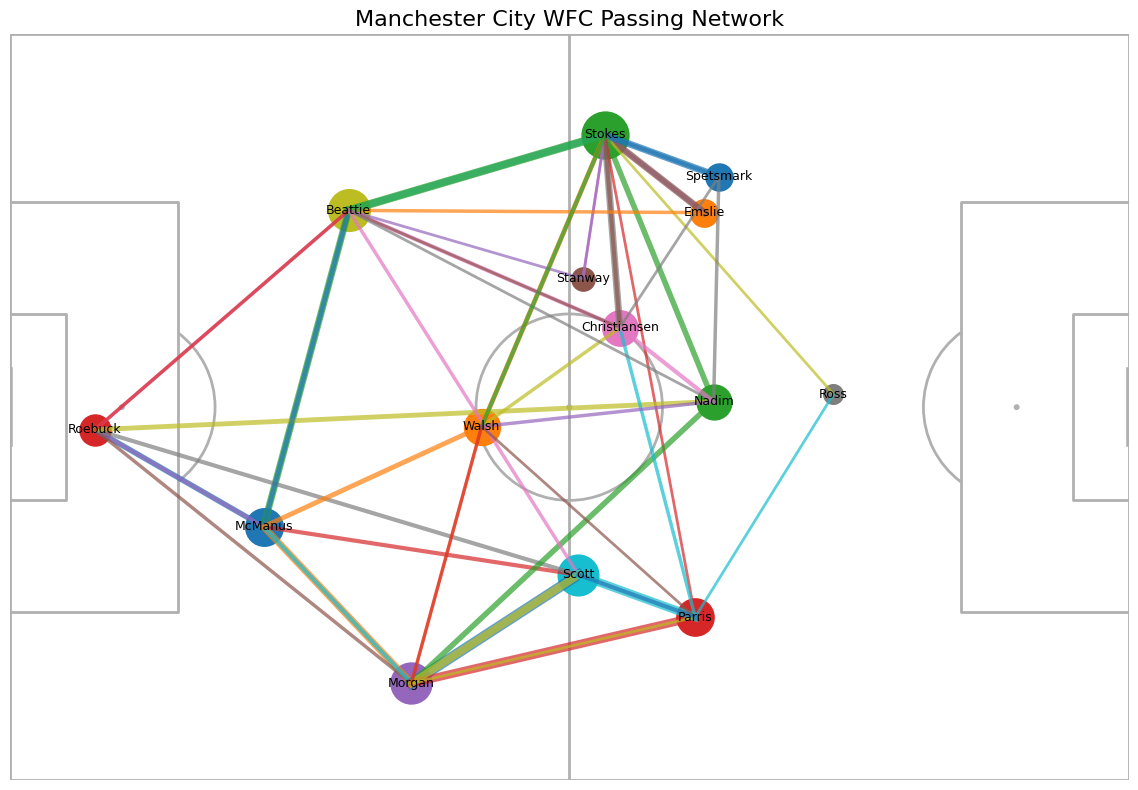

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch

# Load and flatten data
df = pd.read_json("data/events/7298.json")
df = pd.json_normalize(df.to_dict(orient="records"))

# --- Filter passes for Manchester City ---
team_name = df['team.name'].iloc[0]  # auto-picking team 

passes = df[
    (df['type.name'] == 'Pass') &
    (df['team.name'] == team_name) 
].copy()

# Drop missing receivers
passes = passes.dropna(subset=['pass.recipient.name'])

# --- Extract coordinates ---
passes['x'] = passes['location'].apply(lambda loc: loc[0] if isinstance(loc, list) else None)
passes['y'] = passes['location'].apply(lambda loc: loc[1] if isinstance(loc, list) else None)

passes['end_x'] = passes['pass.end_location'].apply(lambda loc: loc[0] if isinstance(loc, list) else None)
passes['end_y'] = passes['pass.end_location'].apply(lambda loc: loc[1] if isinstance(loc, list) else None)

# --- Build passer and receiver positions ---
passers = passes[['player.name', 'x', 'y']].rename(columns={'player.name': 'player'})
receivers = passes[['pass.recipient.name', 'end_x', 'end_y']].rename(
    columns={'pass.recipient.name': 'player', 'end_x': 'x', 'end_y': 'y'}
)

all_players = pd.concat([passers, receivers])
touch_counts = all_players['player'].value_counts().to_dict()

# Average positions
avg_positions = all_players.groupby('player')[['x', 'y']].mean().reset_index()

# --- Pass links ---
pass_links = passes.groupby(
    ['player.name', 'pass.recipient.name']
).size().reset_index(name='count')

# Keep stronger links only
pass_links = pass_links[pass_links['count'] > 3]

# --- Plot ---
pitch = Pitch()
fig, ax = pitch.draw(figsize=(12, 8))

# Pitch
ax.set_xlim(0, 120)
ax.set_ylim(0, 80)
ax.invert_yaxis()
ax.axis('off')  # removes axes

# Draw nodes
for _, row in avg_positions.iterrows():
    size = touch_counts.get(row['player'], 1) * 10

    ax.scatter(row['x'], row['y'], s=size)
    ax.text(row['x'], row['y'], row['player'].split()[-1],
            fontsize=9, ha='center', va='center')

# Lookup
pos_dict = avg_positions.set_index('player')[['x', 'y']].to_dict('index')

# Draw lines
for _, row in pass_links.iterrows():
    p1 = row['player.name']
    p2 = row['pass.recipient.name']
    count = row['count']

    if p1 in pos_dict and p2 in pos_dict:
        x1, y1 = pos_dict[p1]['x'], pos_dict[p1]['y']
        x2, y2 = pos_dict[p2]['x'], pos_dict[p2]['y']

        ax.plot([x1, x2], [y1, y2],
                linewidth=count/2,
                alpha=0.7)  # transparency

ax.set_title(f"{team_name} Passing Network", fontsize=16)

plt.show()